# Prédiction du Risque Cardiovasculaire — Projet DDDM

**Question décisionnelle** : Quels patients sont à risque élevé de maladie coronarienne sur un horizon de 10 ans ?

## Phase 1 — Définition du Problème & KPIs

### KPI Tree

- **Objectif** : Réduire hospitalisations cardiaques non anticipées de 20%
  - KPI Primaire : AUC-ROC > 0.85, Recall > 0.80
  - KPI Secondaire : F1-Score > 0.75
  - KPI Financier : ROI programme prévention > 3x

### Business Case

| Paramètre | Valeur |
|-----------|--------|
| Coût moyen hospitalisation cardiaque | 15 000 € |
| Patients à risque détectables | 1 000 / an |
| Économie annuelle potentielle | 4 500 000 € |
| Coût programme | 500 000 € |
| **ROI** | **8x** |

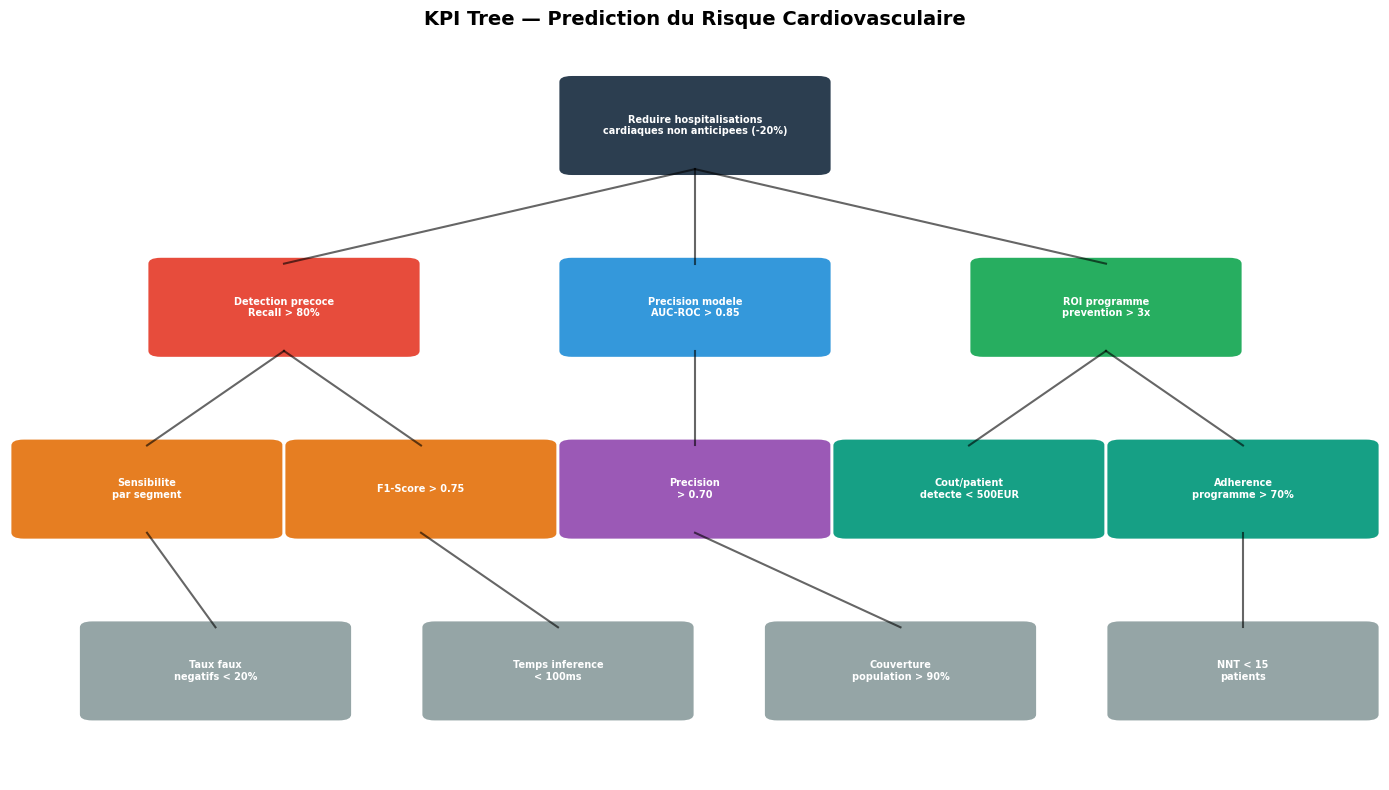

In [1]:
# KPI Tree Visuel (diagramme hierarchique)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Niveaux du KPI Tree
boxes = [
    # Niveau 0 - Objectif strategique
    (5, 9, 'Reduire hospitalisations\ncardiaques non anticipees (-20%)', '#2c3e50', 'white'),
    # Niveau 1 - KPIs primaires
    (2, 6.5, 'Detection precoce\nRecall > 80%', '#e74c3c', 'white'),
    (5, 6.5, 'Precision modele\nAUC-ROC > 0.85', '#3498db', 'white'),
    (8, 6.5, 'ROI programme\nprevention > 3x', '#27ae60', 'white'),
    # Niveau 2 - KPIs secondaires
    (1, 4, 'Sensibilite\npar segment', '#e67e22', 'white'),
    (3, 4, 'F1-Score > 0.75', '#e67e22', 'white'),
    (5, 4, 'Precision\n> 0.70', '#9b59b6', 'white'),
    (7, 4, 'Cout/patient\ndetecte < 500EUR', '#16a085', 'white'),
    (9, 4, 'Adherence\nprogramme > 70%', '#16a085', 'white'),
    # Niveau 3 - Metriques operationnelles
    (1.5, 1.5, 'Taux faux\nnegatifs < 20%', '#95a5a6', 'white'),
    (4, 1.5, 'Temps inference\n< 100ms', '#95a5a6', 'white'),
    (6.5, 1.5, 'Couverture\npopulation > 90%', '#95a5a6', 'white'),
    (9, 1.5, 'NNT < 15\npatients', '#95a5a6', 'white'),
]

for x, y, text, fc, tc in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x-0.9, y-0.6), 1.8, 1.2, boxstyle='round,pad=0.1', 
                                         facecolor=fc, edgecolor='white', linewidth=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=7, color=tc, fontweight='bold')

# Lignes de connexion
for px_s, py_s, px_e, py_e in [(5,8.4,2,7.1),(5,8.4,5,7.1),(5,8.4,8,7.1),
                                (2,5.9,1,4.6),(2,5.9,3,4.6),(5,5.9,5,4.6),
                                (8,5.9,7,4.6),(8,5.9,9,4.6),
                                (1,3.4,1.5,2.1),(3,3.4,4,2.1),(5,3.4,6.5,2.1),(9,3.4,9,2.1)]:
    ax.plot([px_s, px_e], [py_s, py_e], 'k-', lw=1.5, alpha=0.6)

ax.set_title('KPI Tree — Prediction du Risque Cardiovasculaire', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Phase 2 — Collecte & Audit des Données

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Chargement Dataset 1 : Framingham Heart Study
try:
    df_framingham = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "aasheesh200/framingham-heart-study-dataset",
        "framingham.csv"
    )
    print(f"Framingham charge : {df_framingham.shape[0]} lignes, {df_framingham.shape[1]} colonnes")
except Exception as e:
    print(f"Erreur Framingham : {e}")
    raise

# Chargement Dataset 2 : Cardiovascular Disease
try:
    df_cardio = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "sulianova/cardiovascular-disease-dataset",
        "cardio_train.csv",
        pandas_kwargs={"sep": ";"}
    )
    print(f"Cardiovascular charge : {df_cardio.shape[0]} lignes, {df_cardio.shape[1]} colonnes")
except Exception as e:
    print(f"Erreur Cardiovascular : {e}")
    raise

Framingham charge : 4240 lignes, 16 colonnes


Cardiovascular charge : 70000 lignes, 13 colonnes


In [3]:
# Data Audit
def data_audit(df, name):
    print("=" * 60)
    print(f"AUDIT : {name}")
    print("=" * 60)
    print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Manquantes': missing, 'Pct': missing_pct})
    missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Pct', ascending=False)
    if len(missing_df) > 0:
        print("Valeurs manquantes :")
        print(missing_df)
    else:
        print("Aucune valeur manquante")
    dupes = df.duplicated().sum()
    print(f"Doublons : {dupes} ({dupes/len(df)*100:.2f}%)")
    return df.describe()

stats_fram = data_audit(df_framingham, "Framingham Heart Study")
display(stats_fram)
stats_cardio = data_audit(df_cardio, "Cardiovascular Disease")
display(stats_cardio)

AUDIT : Framingham Heart Study
Dimensions : 4240 lignes x 16 colonnes
Valeurs manquantes :
            Manquantes   Pct
glucose            388  9.15
education          105  2.48
BPMeds              53  1.25
totChol             50  1.18
cigsPerDay          29  0.68
BMI                 19  0.45
heartRate            1  0.02
Doublons : 0 (0.00%)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


AUDIT : Cardiovascular Disease
Dimensions : 70000 lignes x 13 colonnes
Aucune valeur manquante
Doublons : 0 (0.00%)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Harmonisation et Fusion

In [4]:
# Harmonisation Cardiovascular : age en jours -> annees
df_cardio_clean = df_cardio.copy()
df_cardio_clean['age'] = (df_cardio_clean['age'] / 365).round(0).astype(int)
df_cardio_clean = df_cardio_clean.rename(columns={
    'ap_hi': 'sysBP', 'ap_lo': 'diaBP', 'gluc': 'glucose',
    'smoke': 'currentSmoker', 'cardio': 'target'
})
cols_cardio = ['age', 'gender', 'sysBP', 'diaBP', 'cholesterol', 'glucose', 'currentSmoker', 'target']
df_cardio_harmonized = df_cardio_clean[cols_cardio].copy()
df_cardio_harmonized['source'] = 'cardiovascular'

# Harmonisation Framingham
df_fram_clean = df_framingham.rename(columns={
    'male': 'gender', 'totChol': 'cholesterol', 'TenYearCHD': 'target'
})
cols_fram = ['age', 'gender', 'sysBP', 'diaBP', 'cholesterol', 'glucose', 'currentSmoker', 'target']
available_cols = [c for c in cols_fram if c in df_fram_clean.columns]
df_fram_harmonized = df_fram_clean[available_cols].copy()
df_fram_harmonized['source'] = 'framingham'

# Fusion
df_merged = pd.concat([df_fram_harmonized, df_cardio_harmonized], ignore_index=True)
print(f"Dataset fusionne : {df_merged.shape}")
print(f"Desequilibre : Framingham {len(df_fram_harmonized)} ({len(df_fram_harmonized)/len(df_merged)*100:.1f}%) vs Cardiovascular {len(df_cardio_harmonized)} ({len(df_cardio_harmonized)/len(df_merged)*100:.1f}%)")
print(f"Cible : {df_merged['target'].value_counts(normalize=True).to_dict()}")

# Imputation mediane
df_merged = df_merged.fillna(df_merged.median(numeric_only=True))
print(f"Valeurs manquantes apres imputation : {df_merged.isnull().sum().sum()}")

Dataset fusionne : (74240, 9)
Desequilibre : Framingham 4240 (5.7%) vs Cardiovascular 70000 (94.3%)
Cible : {0: 0.5201643318965518, 1: 0.4798356681034483}
Valeurs manquantes apres imputation : 0


### Data Dictionary

| Variable | Type | Description | Source |
|----------|------|-------------|--------|
| age | int | Âge en années | Les deux |
| gender | int | Sexe (1=Homme) | Les deux |
| sysBP | float | Tension systolique (mmHg) | Les deux |
| diaBP | float | Tension diastolique (mmHg) | Les deux |
| cholesterol | float | Cholestérol | Les deux |
| glucose | float | Glucose | Les deux |
| currentSmoker | int | Fumeur (1=Oui) | Les deux |
| target | int | Maladie cardiovasculaire (1=Oui) | Les deux |
| source | str | Dataset d'origine | Généré |

### Analyse des Biais

| Type de Biais | Description | Impact | Mitigation |
|---------------|-------------|--------|------------|
| **Biais de sélection** | Framingham = population américaine blanche majoritaire ; Cardiovascular = population est-européenne | Sous-représentation de certaines ethnies, généralisation limitée | Fusion des deux datasets pour diversifier ; documenter les limites |
| **Biais temporel** | Framingham collecté sur 10 ans (cohorte historique) vs Cardiovascular (transversal) | Les pratiques médicales ont évolué, certains facteurs sont datés | Utiliser uniquement les variables cliniques stables dans le temps |
| **Biais de volume** | Cardiovascular (70k) domine Framingham (4.2k) dans le dataset fusionné (94% vs 6%) | Le modèle apprend principalement les patterns du dataset majoritaire | Documenter ce déséquilibre ; analyser les performances par source |
| **Biais de mesure** | Cholestérol : valeur continue (Framingham) vs catégorielle 1/2/3 (Cardiovascular) | Perte d'information lors de l'harmonisation | Conserver les deux échelles et documenter la transformation |
| **Données manquantes structurelles** | Framingham : glucose manquant à 9.15% (non aléatoire — patients non testés = probablement non-diabétiques) | Imputation par médiane peut sous-estimer le risque des diabétiques | Imputation conservatrice ; variable indicatrice possible |
| **Données fantômes** | Pas de variables socio-économiques, alimentation, activité physique, antécédents familiaux | Facteurs de risque importants non capturés → plafond de performance | Documenter comme limitation ; enrichir si données disponibles |

## Phase 3 — EDA & Analyse Statistique

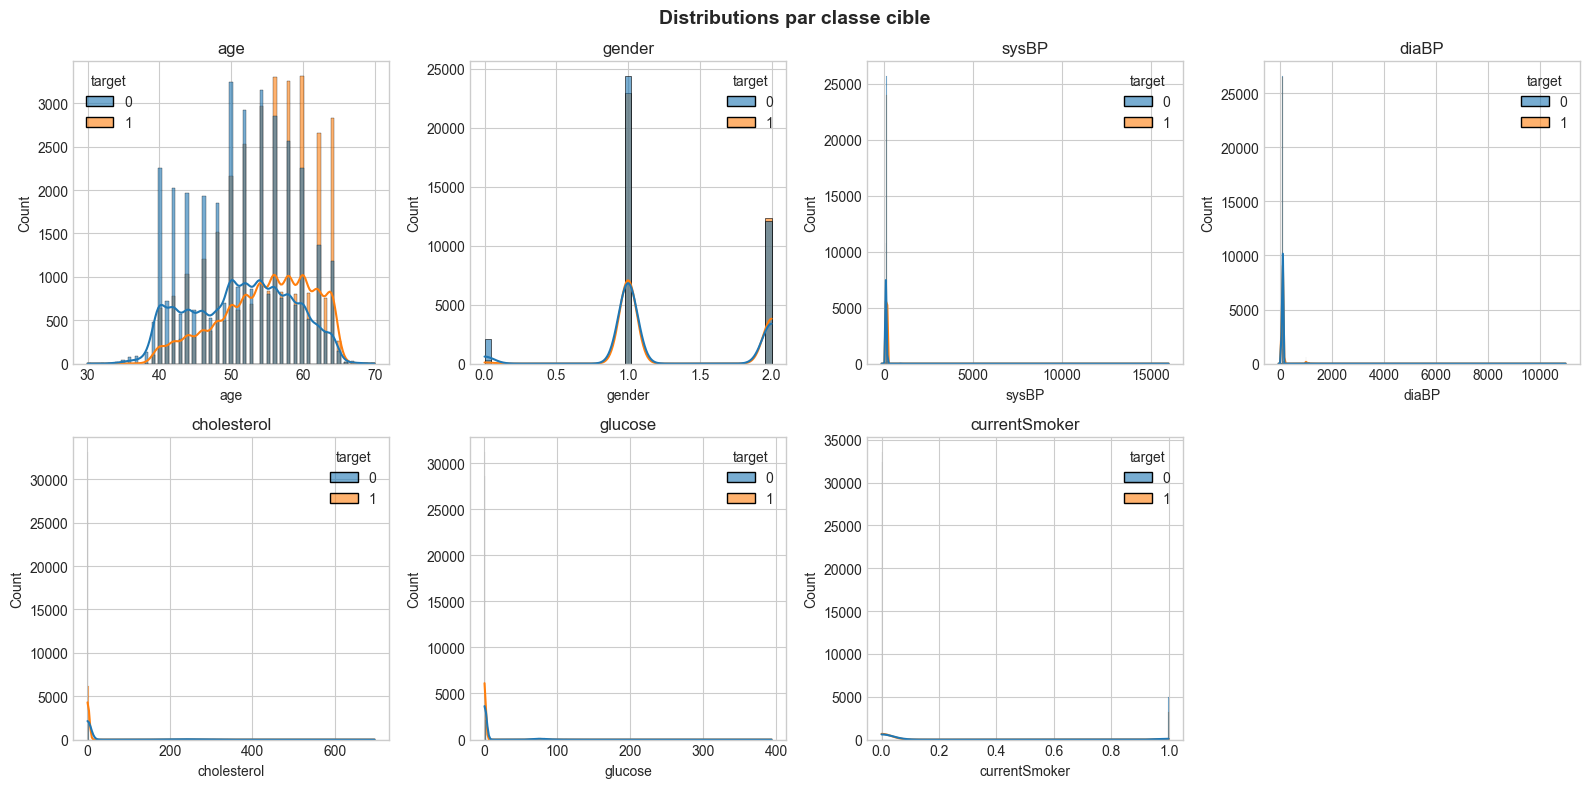

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Distributions
num_cols = [c for c in df_merged.select_dtypes(include=[np.number]).columns if c not in ['target']]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:8]):
    sns.histplot(data=df_merged, x=col, hue='target', kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col}')
for j in range(i+1, 8):
    axes[j].set_visible(False)
plt.suptitle('Distributions par classe cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

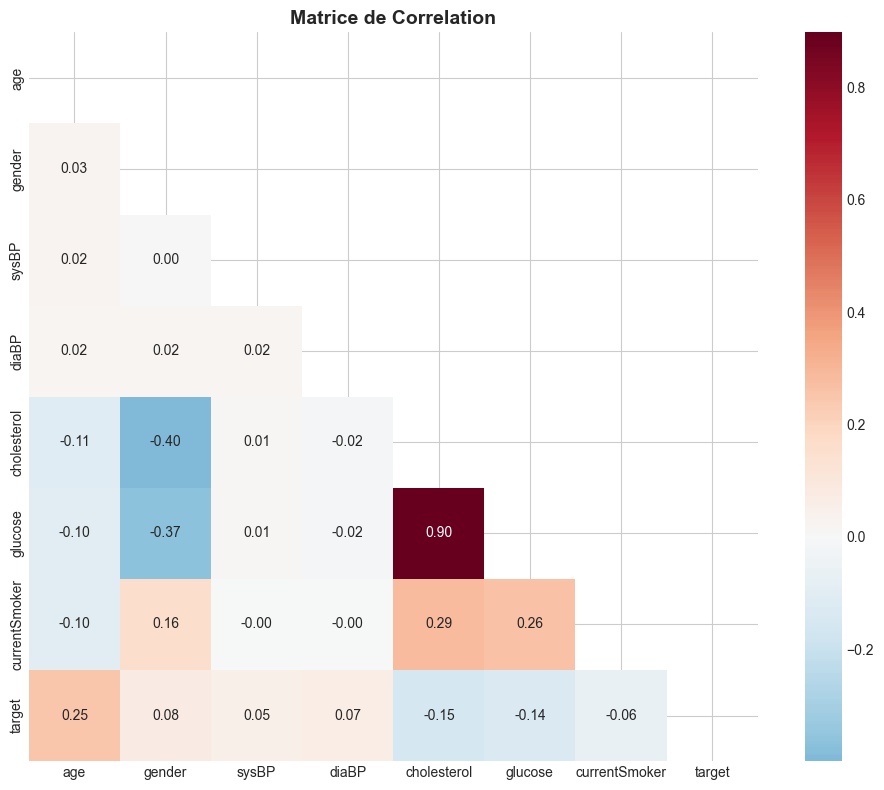

In [6]:
# Heatmap de correlation
plt.figure(figsize=(10, 8))
corr_matrix = df_merged.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Matrice de Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

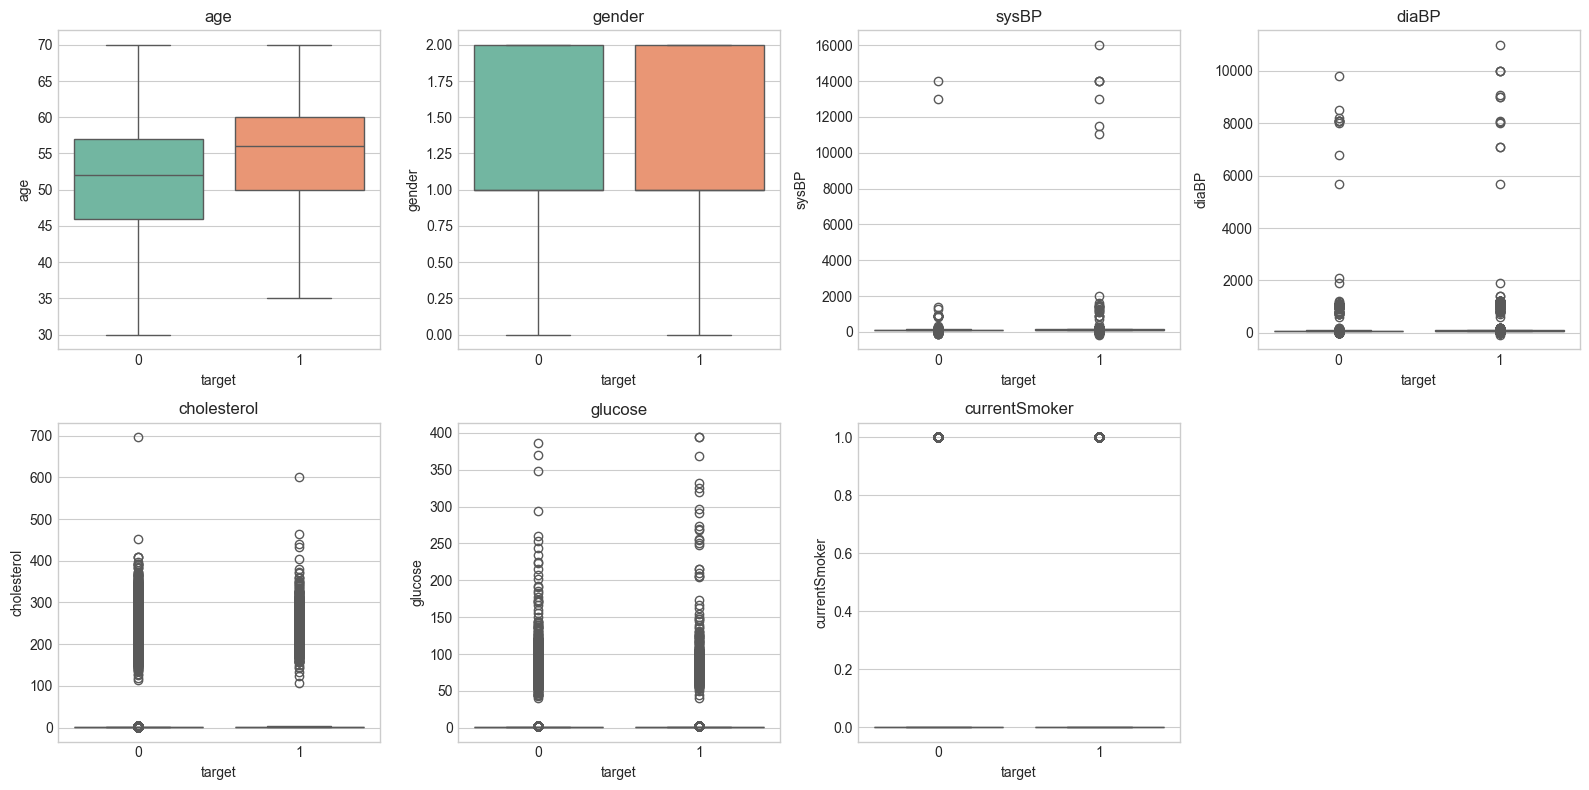

In [7]:
# Boxplots par classe
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:8]):
    sns.boxplot(data=df_merged, x='target', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
for j in range(i+1, 8):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

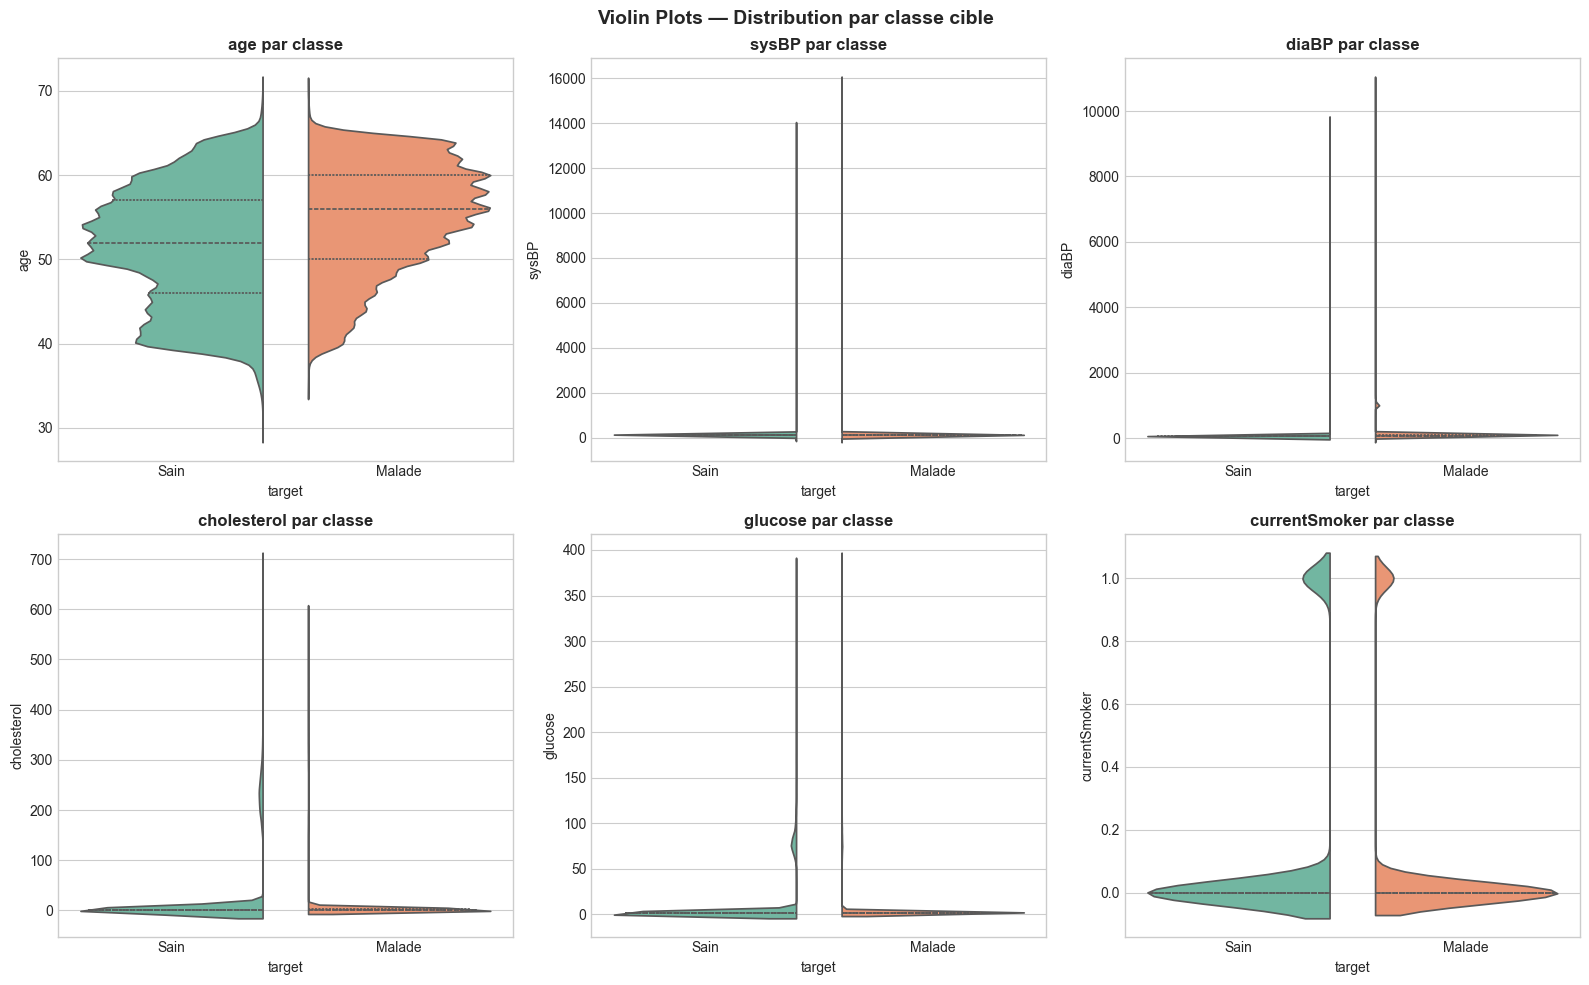

In [8]:
# Violin plots par classe
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
violin_cols = ['age', 'sysBP', 'diaBP', 'cholesterol', 'glucose', 'currentSmoker']
for i, col in enumerate(violin_cols):
    sns.violinplot(data=df_merged, x='target', y=col, ax=axes[i], palette='Set2', split=True, inner='quartile')
    axes[i].set_title(f'{col} par classe', fontweight='bold')
    axes[i].set_xticklabels(['Sain', 'Malade'])
plt.suptitle('Violin Plots — Distribution par classe cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

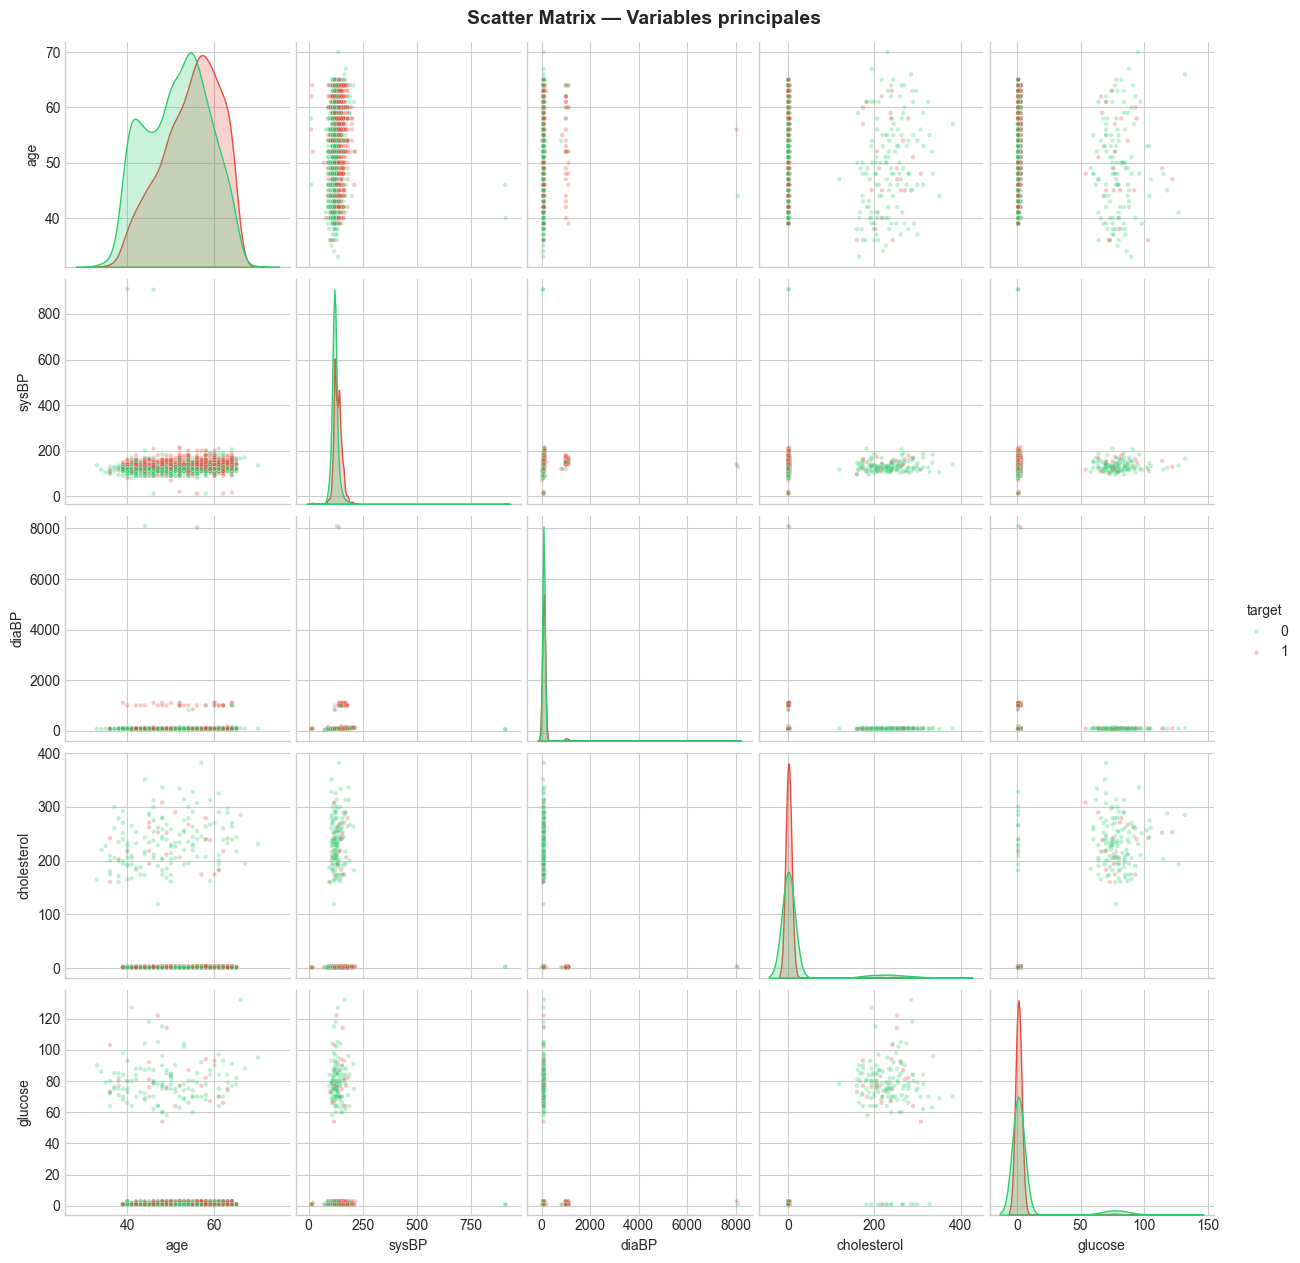

In [9]:
# Scatter Matrix (Pairplot)
sample = df_merged[['age', 'sysBP', 'diaBP', 'cholesterol', 'glucose', 'target']].sample(3000, random_state=42)
g = sns.pairplot(sample, hue='target', palette={0: '#2ecc71', 1: '#e74c3c'}, 
                 diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
g.fig.suptitle('Scatter Matrix — Variables principales', y=1.01, fontsize=14, fontweight='bold')
plt.show()

In [10]:
# Tests statistiques
from scipy import stats

print("TESTS STATISTIQUES")
print("=" * 60)
results_tests = []
for col in num_cols:
    g0 = df_merged[df_merged['target'] == 0][col].dropna()
    g1 = df_merged[df_merged['target'] == 1][col].dropna()
    stat_mw, p_mw = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    stat_t, p_t = stats.ttest_ind(g0, g1)
    sig = '***' if p_mw < 0.001 else '**' if p_mw < 0.01 else '*' if p_mw < 0.05 else 'ns'
    results_tests.append({'Variable': col, 'Moy_Sain': f"{g0.mean():.2f}", 'Moy_Malade': f"{g1.mean():.2f}",
                         'Mann-Whitney_p': f"{p_mw:.2e}", 'Sig': sig})
print(pd.DataFrame(results_tests).to_string(index=False))

# Chi-deux
print("\nTEST CHI-DEUX")
for var in ['gender', 'currentSmoker']:
    if var in df_merged.columns:
        ct = pd.crosstab(df_merged[var], df_merged['target'])
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        print(f"  {var}: Chi2={chi2:.2f}, p={p:.2e}")

TESTS STATISTIQUES
     Variable Moy_Sain Moy_Malade Mann-Whitney_p Sig
          age    51.45      54.93       0.00e+00 ***
       gender     1.26       1.34       2.76e-71 ***
        sysBP   121.35     137.33       0.00e+00 ***
        diaBP    84.06     108.63       0.00e+00 ***
  cholesterol    22.75       5.86      7.60e-169 ***
      glucose     7.88       2.74       8.19e-03  **
currentSmoker     0.13       0.09       1.20e-60 ***

TEST CHI-DEUX
  gender: Chi2=1293.10, p=1.61e-281
  currentSmoker: Chi2=269.51, p=1.45e-60


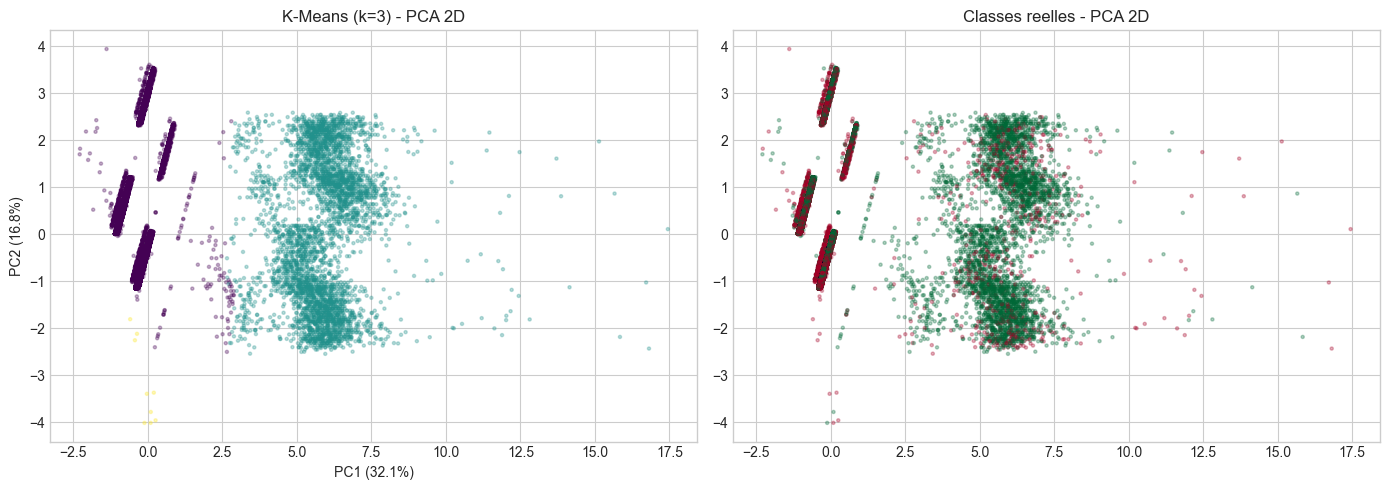

Profil moyen par cluster :
           age  gender     sysBP  diaBP  cholesterol  glucose  currentSmoker  \
cluster                                                                        
0        53.33    1.35    127.12  96.61         1.54     1.23           0.09   
1        49.55    0.43    132.29  82.88       236.96    76.38           0.50   
2        52.56    1.33  13404.44  83.33         1.44     1.33           0.00   

         target  
cluster          
0          0.50  
1          0.15  
2          0.78  


In [11]:
# Clustering K-Means
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_cluster = df_merged.select_dtypes(include=[np.number]).drop(columns=['target']).dropna()
scaler_c = StandardScaler()
X_scaled_c = scaler_c.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_c)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.3, s=5)
axes[0].set_title('K-Means (k=3) - PCA 2D')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

targets_a = df_merged.loc[X_cluster.index, 'target'].values
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=targets_a, cmap='RdYlGn_r', alpha=0.3, s=5)
axes[1].set_title('Classes reelles - PCA 2D')
plt.tight_layout()
plt.show()

# Profil clusters
df_ca = df_merged.loc[X_cluster.index].copy()
df_ca['cluster'] = clusters
print("Profil moyen par cluster :")
print(df_ca.groupby('cluster').mean(numeric_only=True).round(2))

In [12]:
# Detection outliers IQR
continuous_cols = [c for c in ['age', 'sysBP', 'diaBP', 'cholesterol', 'glucose'] if c in df_merged.columns]
print("DETECTION OUTLIERS (IQR)")
df_clean = df_merged.copy()
for col in continuous_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers ({n_out/len(df_clean)*100:.2f}%)")
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
print(f"Observations conservees : {len(df_clean)}")

DETECTION OUTLIERS (IQR)
  age: 5 outliers (0.01%)
  sysBP: 1710 outliers (2.30%)
  diaBP: 4979 outliers (6.71%)
  cholesterol: 4190 outliers (5.64%)
  glucose: 14373 outliers (19.36%)
Observations conservees : 74240


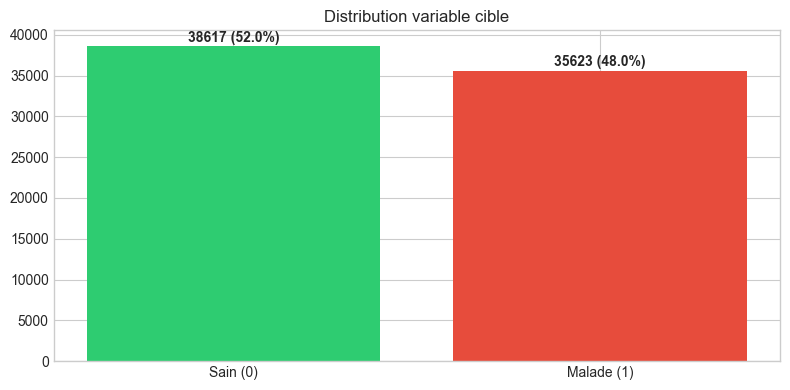

Ratio : 1.08:1


In [13]:
# Analyse desequilibre classes
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
tc = df_clean['target'].value_counts()
ax.bar(['Sain (0)', 'Malade (1)'], tc.values, color=['#2ecc71', '#e74c3c'])
for i, v in enumerate(tc.values):
    ax.text(i, v + 500, f'{v} ({v/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribution variable cible')
plt.tight_layout()
plt.show()
print(f"Ratio : {tc[0]/tc[1]:.2f}:1")

## Phase 4 — Modélisation & Interprétabilité

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_curve, precision_recall_curve)
import xgboost as xgb
import joblib

# Feature engineering
df_model = df_clean.copy()
df_model['bp_ratio'] = df_model['sysBP'] / df_model['diaBP'].replace(0, 1)
df_model['pulse_pressure'] = df_model['sysBP'] - df_model['diaBP']
df_model = df_model.drop(columns=['source'])

X = df_model.drop(columns=['target'])
y = df_model['target']
feature_names = list(X.columns)
print(f"Features ({X.shape[1]}): {feature_names}")
print(f"Dataset : {X.shape[0]} obs, Cible : {y.value_counts().to_dict()}")

Features (9): ['age', 'gender', 'sysBP', 'diaBP', 'cholesterol', 'glucose', 'currentSmoker', 'bp_ratio', 'pulse_pressure']
Dataset : 74240 obs, Cible : {0: 38617, 1: 35623}


In [15]:
# Split stratifie 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: 59392, Test: 14848


In [16]:
# Modele 1 : Regression Logistique
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
print(f"Reg. Logistique - AUC(CV): {lr_cv.mean():.4f}, AUC(test): {roc_auc_score(y_test, lr_proba):.4f}, F1: {f1_score(y_test, lr_pred):.4f}, Recall: {recall_score(y_test, lr_pred):.4f}")

Reg. Logistique - AUC(CV): 0.7696, AUC(test): 0.7757, F1: 0.6925, Recall: 0.6740


In [17]:
# Modele 2 : Random Forest + GridSearch
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf, rf_params, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_scaled)
rf_proba = rf_best.predict_proba(X_test_scaled)[:, 1]
print(f"Random Forest - Best params: {rf_grid.best_params_}")
print(f"  AUC(test): {roc_auc_score(y_test, rf_proba):.4f}, F1: {f1_score(y_test, rf_pred):.4f}, Recall: {recall_score(y_test, rf_pred):.4f}")

Random Forest - Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
  AUC(test): 0.8078, F1: 0.7191, Recall: 0.6916


In [18]:
# Modele 3 : XGBoost + GridSearch
scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_params = {'n_estimators': [100, 200], 'max_depth': [4, 6], 'learning_rate': [0.05, 0.1]}
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_ratio, random_state=42, eval_metric='auc')
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test_scaled)
xgb_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]
print(f"XGBoost - Best params: {xgb_grid.best_params_}")
print(f"  AUC(test): {roc_auc_score(y_test, xgb_proba):.4f}, F1: {f1_score(y_test, xgb_pred):.4f}, Recall: {recall_score(y_test, xgb_pred):.4f}")

XGBoost - Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
  AUC(test): 0.8101, F1: 0.7239, Recall: 0.7072


In [19]:
# Comparaison des modeles
results = pd.DataFrame({
    'Modele': ['Reg. Logistique', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, xgb_proba)],
    'F1': [f1_score(y_test, lr_pred), f1_score(y_test, rf_pred), f1_score(y_test, xgb_pred)],
    'Recall': [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred), recall_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)]
})
print(results.to_string(index=False))
best_idx = results['AUC-ROC'].idxmax()
print(f"\nMeilleur modele : {results.loc[best_idx, 'Modele']} (AUC={results.loc[best_idx, 'AUC-ROC']:.4f})")

         Modele  AUC-ROC       F1   Recall  Precision
Reg. Logistique 0.775691 0.692480 0.673965   0.712040
  Random Forest 0.807775 0.719101 0.691649   0.748822
        XGBoost 0.810056 0.723890 0.707228   0.741356

Meilleur modele : XGBoost (AUC=0.8101)


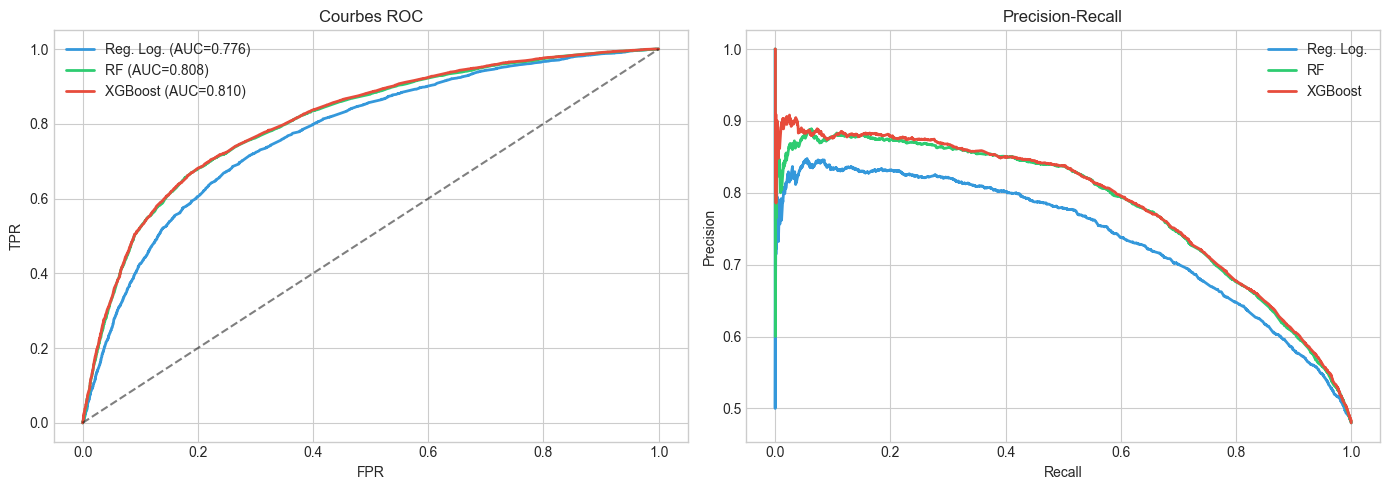

In [20]:
# Courbes ROC comparatives
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, proba, color in [('Reg. Log.', lr_proba, '#3498db'), ('RF', rf_proba, '#2ecc71'), ('XGBoost', xgb_proba, '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
axes[0].set_title('Courbes ROC')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

for name, proba, color in [('Reg. Log.', lr_proba, '#3498db'), ('RF', rf_proba, '#2ecc71'), ('XGBoost', xgb_proba, '#e74c3c')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=name)
axes[1].set_title('Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
plt.tight_layout()
plt.show()

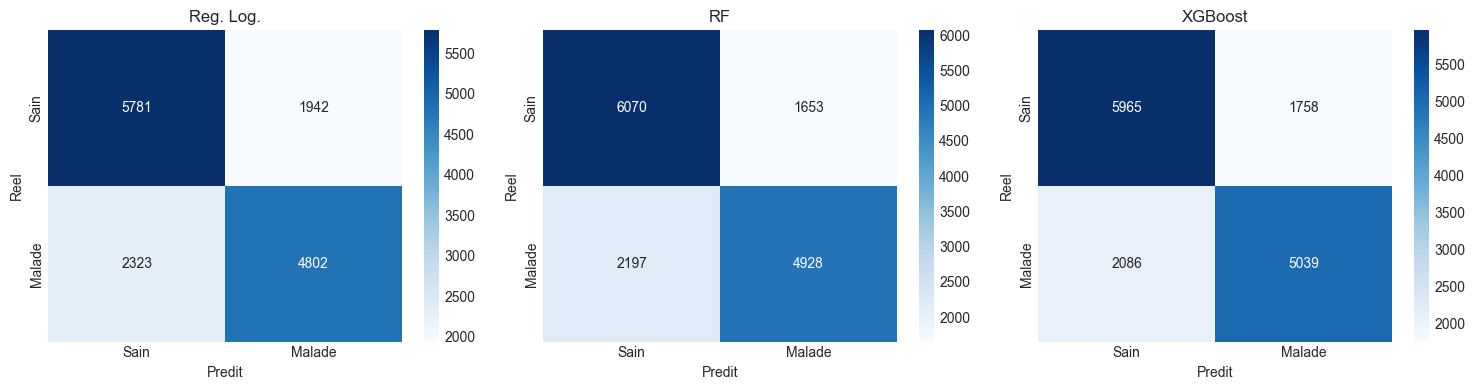

In [21]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, pred) in enumerate([('Reg. Log.', lr_pred), ('RF', rf_pred), ('XGBoost', xgb_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=['Sain','Malade'], yticklabels=['Sain','Malade'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Reel')
    axes[i].set_xlabel('Predit')
plt.tight_layout()
plt.show()

### Interprétabilité SHAP

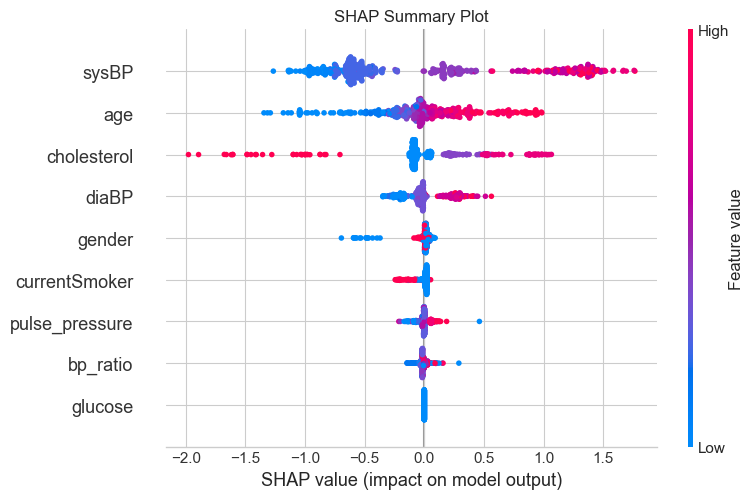

In [22]:
import shap
# SHAP sur XGBoost
X_sample = X_test_scaled[:500]
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

Haut Risque - Score: 90.43%


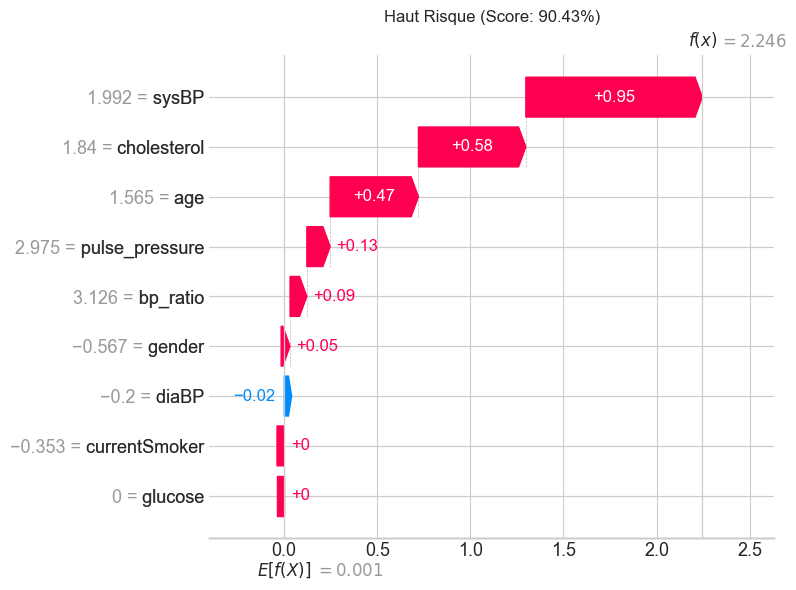

Risque Modere - Score: 48.40%


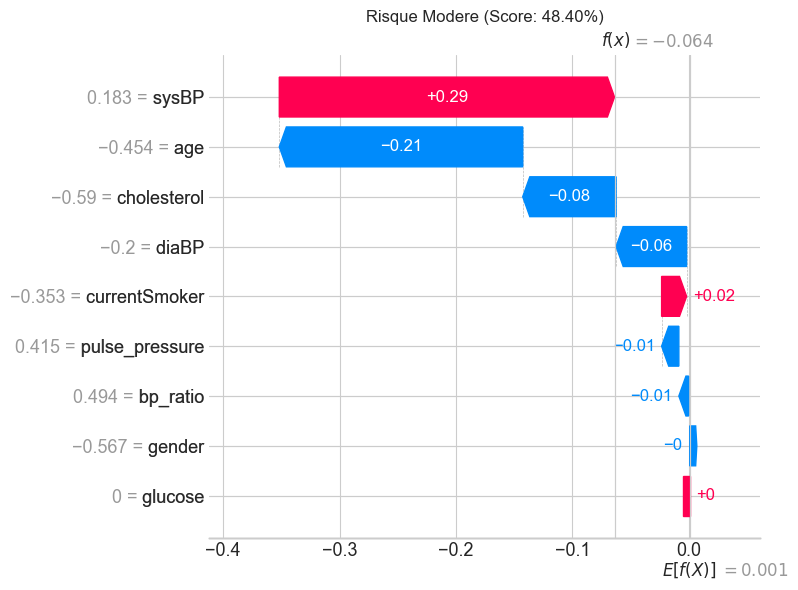

Faible Risque - Score: 2.24%


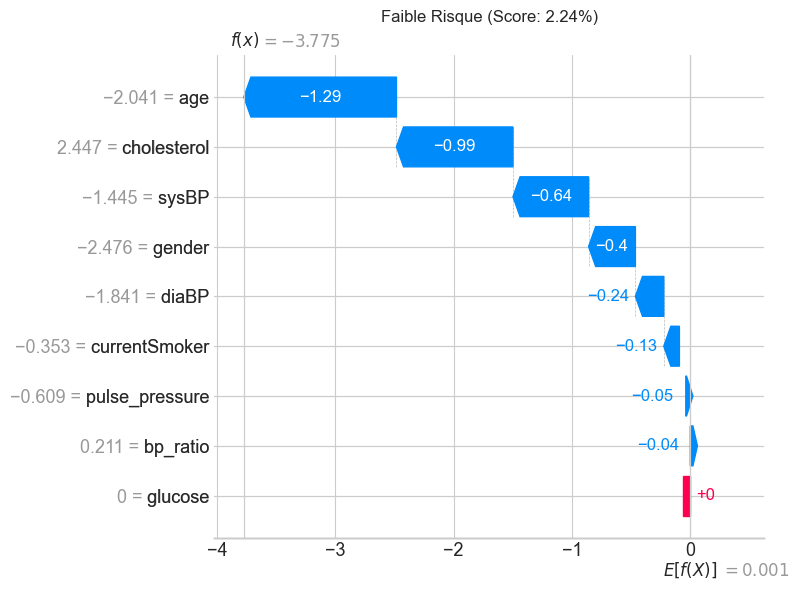

In [23]:
# SHAP Waterfall - 3 patients
risk_scores = xgb_best.predict_proba(X_sample)[:, 1]
indices = [np.argmax(risk_scores), np.argsort(risk_scores)[len(risk_scores)//2], np.argmin(risk_scores)]
labels = ['Haut Risque', 'Risque Modere', 'Faible Risque']

for idx, label in zip(indices, labels):
    print(f"{label} - Score: {risk_scores[idx]:.2%}")
    explanation = shap.Explanation(values=shap_values[idx], base_values=explainer.expected_value,
                                   data=X_sample[idx], feature_names=feature_names)
    shap.waterfall_plot(explanation, show=False)
    plt.title(f'{label} (Score: {risk_scores[idx]:.2%})')
    plt.tight_layout()
    plt.show()

In [24]:
# Sauvegarde du meilleur modele
best_model = xgb_best
joblib.dump({
    'model': best_model, 'scaler': scaler, 'feature_names': feature_names,
    'metrics': {'auc_roc': roc_auc_score(y_test, xgb_proba), 'f1_score': f1_score(y_test, xgb_pred),
                'recall': recall_score(y_test, xgb_pred), 'precision': precision_score(y_test, xgb_pred)}
}, '../models/best_model.pkl')
print("best_model.pkl sauvegarde")

best_model.pkl sauvegarde


## Phase 5 — Visualisations Décisionnelles

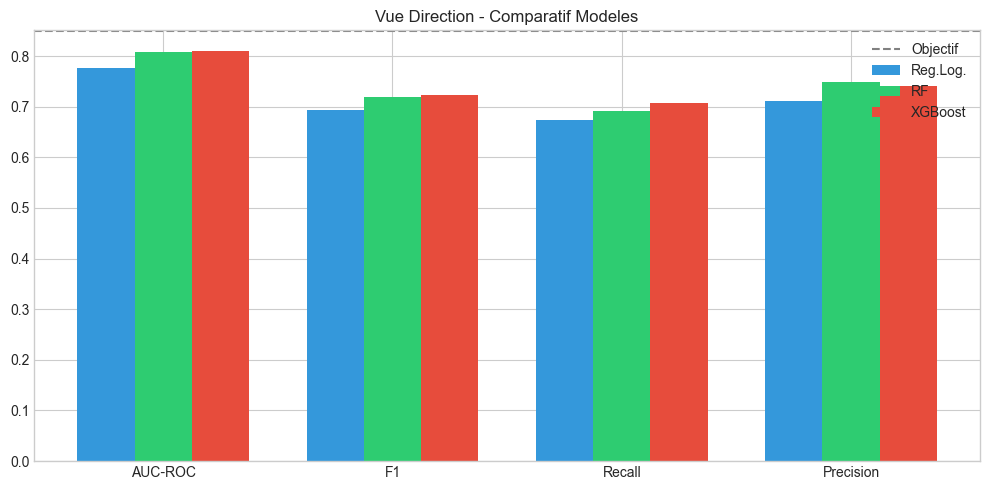

In [25]:
# Vue 1 : Direction - KPIs
fig, ax = plt.subplots(figsize=(10, 5))
metrics_names = ['AUC-ROC', 'F1', 'Recall', 'Precision']
x = np.arange(4)
w = 0.25
lr_m = [roc_auc_score(y_test, lr_proba), f1_score(y_test, lr_pred), recall_score(y_test, lr_pred), precision_score(y_test, lr_pred)]
rf_m = [roc_auc_score(y_test, rf_proba), f1_score(y_test, rf_pred), recall_score(y_test, rf_pred), precision_score(y_test, rf_pred)]
xgb_m = [roc_auc_score(y_test, xgb_proba), f1_score(y_test, xgb_pred), recall_score(y_test, xgb_pred), precision_score(y_test, xgb_pred)]
ax.bar(x-w, lr_m, w, label='Reg.Log.', color='#3498db')
ax.bar(x, rf_m, w, label='RF', color='#2ecc71')
ax.bar(x+w, xgb_m, w, label='XGBoost', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.axhline(0.85, ls='--', c='gray', label='Objectif')
ax.legend()
ax.set_title('Vue Direction - Comparatif Modeles')
plt.tight_layout()
plt.show()

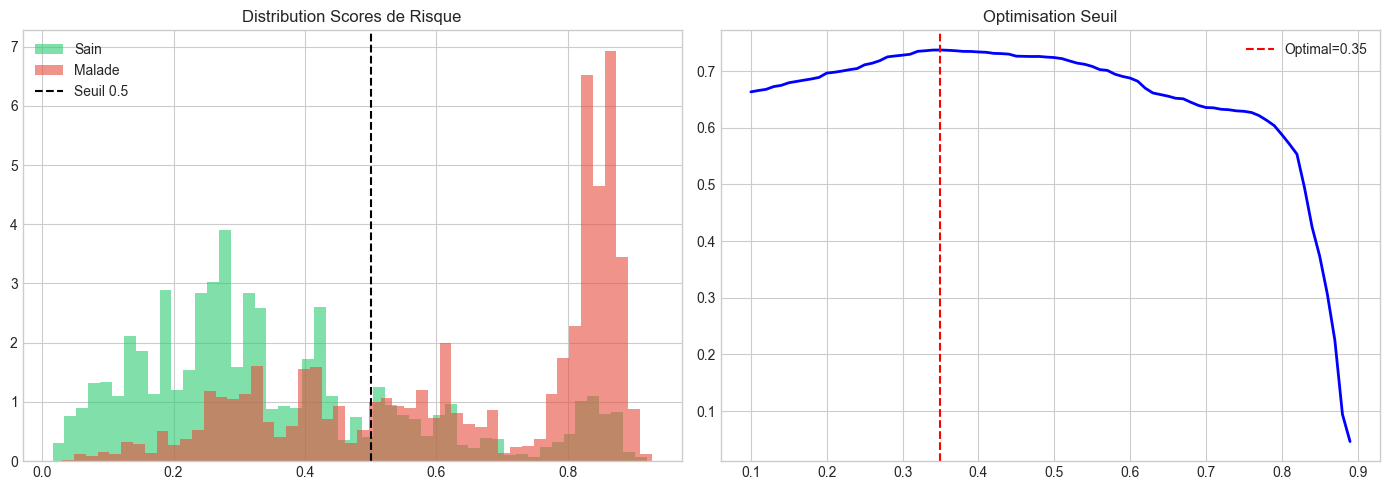

Seuil optimal : 0.35 (F1=0.7372)


In [26]:
# Vue 2 : Operations - Scores de risque
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(xgb_proba[y_test==0], bins=50, alpha=0.6, color='#2ecc71', label='Sain', density=True)
axes[0].hist(xgb_proba[y_test==1], bins=50, alpha=0.6, color='#e74c3c', label='Malade', density=True)
axes[0].axvline(0.5, color='black', ls='--', label='Seuil 0.5')
axes[0].legend()
axes[0].set_title('Distribution Scores de Risque')

thresholds = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_test, (xgb_proba >= t).astype(int)) for t in thresholds]
opt_t = thresholds[np.argmax(f1s)]
axes[1].plot(thresholds, f1s, 'b-', lw=2)
axes[1].axvline(opt_t, color='red', ls='--', label=f'Optimal={opt_t:.2f}')
axes[1].set_title('Optimisation Seuil')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Seuil optimal : {opt_t:.2f} (F1={max(f1s):.4f})")

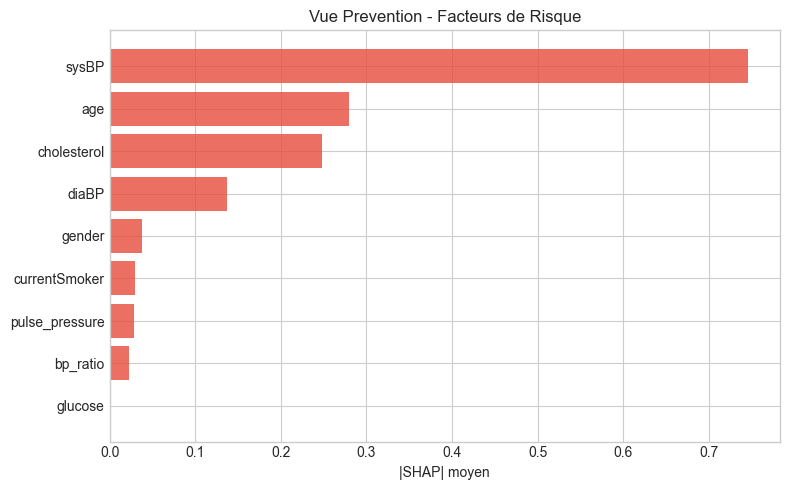

In [27]:
# Vue 3 : Prevention - Top SHAP
fig, ax = plt.subplots(figsize=(8, 5))
shap_imp = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(shap_imp)[::-1]
ax.barh(range(len(feature_names)), shap_imp[sorted_idx], color='#e74c3c', alpha=0.8)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('|SHAP| moyen')
ax.set_title('Vue Prevention - Facteurs de Risque')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

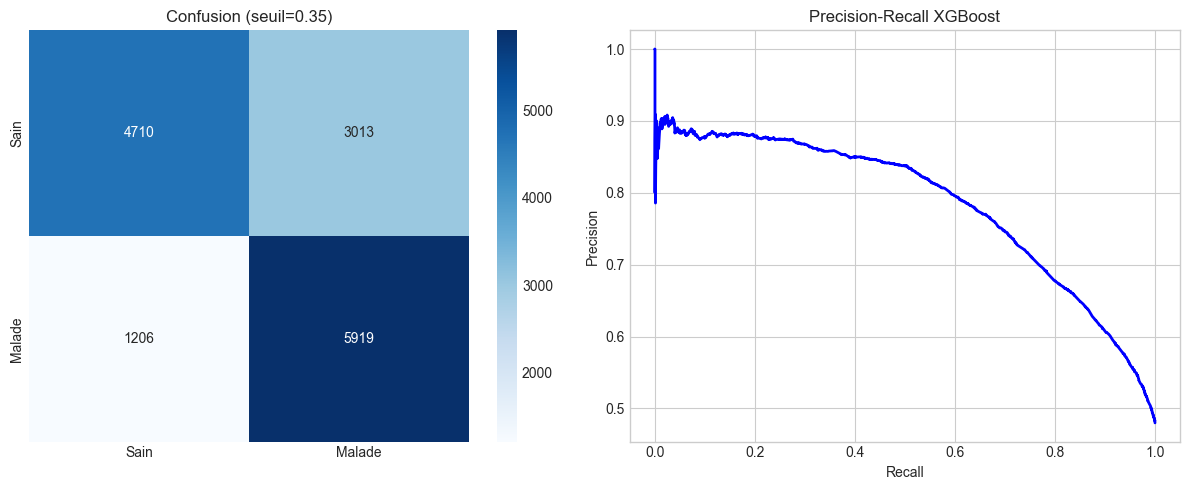

              precision    recall  f1-score   support

        Sain       0.80      0.61      0.69      7723
      Malade       0.66      0.83      0.74      7125

    accuracy                           0.72     14848
   macro avg       0.73      0.72      0.71     14848
weighted avg       0.73      0.72      0.71     14848



In [28]:
# Vue 4 : Clinique - Confusion + PR
xgb_pred_opt = (xgb_proba >= opt_t).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, xgb_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Sain','Malade'], yticklabels=['Sain','Malade'])
axes[0].set_title(f'Confusion (seuil={opt_t:.2f})')
prec_v, rec_v, _ = precision_recall_curve(y_test, xgb_proba)
axes[1].plot(rec_v, prec_v, 'b-', lw=2)
axes[1].set_title('Precision-Recall XGBoost')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
plt.tight_layout()
plt.show()
print(classification_report(y_test, xgb_pred_opt, target_names=['Sain', 'Malade']))

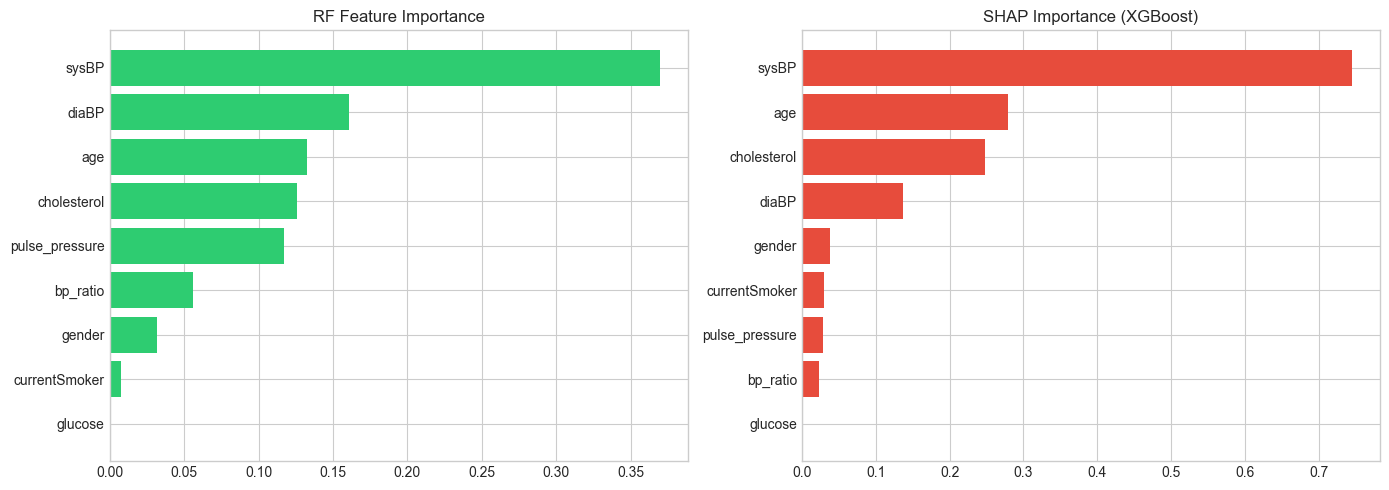

In [29]:
# Vue 5 : Feature Importance RF vs SHAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_imp = rf_best.feature_importances_
rf_sorted = np.argsort(rf_imp)[::-1]
axes[0].barh(range(len(feature_names)), rf_imp[rf_sorted], color='#2ecc71')
axes[0].set_yticks(range(len(feature_names)))
axes[0].set_yticklabels([feature_names[i] for i in rf_sorted])
axes[0].set_title('RF Feature Importance')
axes[0].invert_yaxis()

axes[1].barh(range(len(feature_names)), shap_imp[sorted_idx], color='#e74c3c')
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels([feature_names[i] for i in sorted_idx])
axes[1].set_title('SHAP Importance (XGBoost)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## Phase 6 — Décision & Impact

In [30]:
# Recommandations et impact financier
auc_best = roc_auc_score(y_test, xgb_proba)
recall_best = recall_score(y_test, xgb_pred_opt)
n_high = (xgb_proba >= opt_t).sum()
prevalence = y_test.mean()

print("RECOMMANDATIONS ACTIONNABLES")
print("=" * 60)
print(f"1. Deployer scoring XGBoost (AUC={auc_best:.3f}, Recall={recall_best:.3f})")
print(f"2. Programme prevention pour patients score >= {opt_t:.2f} ({n_high} detectes)")
print(f"3. Dashboard temps reel pour cardiologues")

print("\nIMPACT FINANCIER")
print("=" * 60)
cout_hospi = 15000
pop = 10000
patients_risque = int(pop * prevalence)
detectes = int(patients_risque * recall_best)
evites = int(detectes * 0.20)
economie = evites * cout_hospi
print(f"Population screenee/an : {pop}")
print(f"Patients risque : {patients_risque}")
print(f"Detectes (Recall={recall_best:.0%}) : {detectes}")
print(f"Hospitalisations evitees (20%) : {evites}")
print(f"Economie brute : {economie:,} EUR")
print(f"Cout programme : 500,000 EUR")
print(f"ROI : {economie/500000:.1f}x")

RECOMMANDATIONS ACTIONNABLES
1. Deployer scoring XGBoost (AUC=0.810, Recall=0.831)
2. Programme prevention pour patients score >= 0.35 (8932 detectes)
3. Dashboard temps reel pour cardiologues

IMPACT FINANCIER
Population screenee/an : 10000
Patients risque : 4798
Detectes (Recall=83%) : 3985
Hospitalisations evitees (20%) : 797
Economie brute : 11,955,000 EUR
Cout programme : 500,000 EUR
ROI : 23.9x


In [31]:
# Resume executif
print("RESUME EXECUTIF")
print("=" * 60)
print(f"Modele : XGBoost | AUC-ROC : {auc_best:.3f} | Recall : {recall_best:.3f}")
print(f"Top facteurs : {[feature_names[i] for i in sorted_idx[:5]]}")
print(f"Seuil optimal : {opt_t:.2f}")
print(f"Impact : ~{evites} hospitalisations evitees/an = {economie:,} EUR economises")
print(f"Prochaine etape : A/B test sur 3040 patients, 6 mois")
print("\nNotebook execute avec succes.")

RESUME EXECUTIF
Modele : XGBoost | AUC-ROC : 0.810 | Recall : 0.831
Top facteurs : ['sysBP', 'age', 'cholesterol', 'diaBP', 'gender']
Seuil optimal : 0.35
Impact : ~797 hospitalisations evitees/an = 11,955,000 EUR economises
Prochaine etape : A/B test sur 3040 patients, 6 mois

Notebook execute avec succes.
